# EXPT NO: 8 — Association Rule Learning (Apriori Algorithm) and Dimensionality Reduction (PCA)
**Date:** 08.04.2026

---

## PRE-LAB QUESTIONS

**1. What is Association Rule Mining?**  
Association Rule Mining is an unsupervised learning technique used to discover interesting relationships, patterns, or associations among variables in large transactional databases. It finds rules like "if a customer buys bread, they are likely to buy butter."

**2. What is the Apriori Algorithm?**  
Apriori is a classic algorithm for mining frequent itemsets and generating association rules. It works level-by-level (breadth-first) using the anti-monotone property: if an itemset is infrequent, all its supersets are also infrequent.

**3. What are support, confidence, and lift?**  
- **Support**: Fraction of transactions containing a given itemset. `Support(A) = count(A) / total_transactions`
- **Confidence**: Conditional probability of the consequent given the antecedent. `Confidence(A→B) = Support(A∪B) / Support(A)`
- **Lift**: Ratio of confidence to expected confidence under independence. `Lift(A→B) = Confidence(A→B) / Support(B)`. Lift > 1 indicates a positive association.

**4. What is a frequent itemset?**  
A frequent itemset is a set of items that appears in at least a minimum specified proportion (minimum support threshold) of all transactions.

**5. What is dimensionality reduction?**  
Dimensionality reduction is the process of reducing the number of features in a dataset while preserving as much information (variance) as possible. It helps mitigate the curse of dimensionality, reduces noise, and speeds up learning algorithms.

**6. What is Principal Component Analysis (PCA)?**  
PCA is a linear, unsupervised dimensionality reduction technique that projects data onto a new set of orthogonal axes (principal components) ordered by the amount of variance they explain.

**7. What is variance in data?**  
Variance is a statistical measure of how spread out the values of a feature are around the mean. High variance indicates that data points are far from the mean, while low variance means they are clustered close to it.

**8. Why is feature reduction important in machine learning?**  
Feature reduction reduces computational cost, removes irrelevant or redundant features, prevents overfitting, and can improve model interpretability and accuracy by keeping only the most informative components.

---

## SCENARIO 1 — ASSOCIATION RULE MINING USING APRIORI ALGORITHM

**Problem Statement:** Identify frequent itemsets and generate association rules from transactional grocery data using the Apriori algorithm.

**Dataset:** Groceries Dataset (`Groceries_dataset.csv`)

### Task 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

import networkx as nx

print("All libraries imported successfully!")

All libraries imported successfully!


### Task 2: Load the Dataset

In [2]:
df = pd.read_csv('Groceries_dataset.csv')
print("Shape:", df.shape)
print("\nFirst 10 rows:")
df.head(10)

Shape: (38765, 3)

First 10 rows:


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
5,4941,14-02-2015,rolls/buns
6,4501,08-05-2015,other vegetables
7,3803,23-12-2015,pot plants
8,2762,20-03-2015,whole milk
9,4119,12-02-2015,tropical fruit


In [3]:
print("Dataset Info:")
df.info()
print("\nUnique members:", df['Member_number'].nunique())
print("Unique items:  ", df['itemDescription'].nunique())
print("\nTop 15 most purchased items:")
print(df['itemDescription'].value_counts().head(15))

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Member_number    38765 non-null  int64
 1   Date             38765 non-null  str  
 2   itemDescription  38765 non-null  str  
dtypes: int64(1), str(2)
memory usage: 908.7 KB

Unique members: 3898
Unique items:   167

Top 15 most purchased items:
itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
pastry               785
pip fruit            744
shopping bags        731
canned beer          717
bottled beer         687
Name: count, dtype: int64


### Task 3: Data Preprocessing — Convert to One-Hot Encoding Format

In [4]:
# Group items by Member_number to form transaction baskets
basket = df.groupby('Member_number')['itemDescription'].apply(list).reset_index()
basket.columns = ['Member_number', 'items']

print("Number of transactions (baskets):", len(basket))
print("\nSample transactions:")
basket.head(5)

Number of transactions (baskets):

 3898

Sample transactions:


,Member_number,items
0,1000,"[soda, canned beer, sausage, sausage, whole mi..."
1,1001,"[frankfurter, frankfurter, beef, sausage, whol..."
2,1002,"[tropical fruit, butter milk, butter, frozen v..."
3,1003,"[sausage, root vegetables, rolls/buns, deterge..."
4,1004,"[other vegetables, pip fruit, root vegetables,..."


In [5]:
# Use TransactionEncoder to create a binary (one-hot) matrix
transactions = basket['items'].tolist()

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print("Encoded matrix shape:", df_encoded.shape)
df_encoded.head(5)

Encoded matrix shape: (3898, 167)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,True,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


### Task 4 & 5: Generate Frequent Itemsets Using Apriori (min_support = 0.05)

In [6]:
# Apply Apriori with minimum support of 5%
frequent_itemsets = apriori(df_encoded, min_support=0.05, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print("Total frequent itemsets found:", len(frequent_itemsets))
print("\nBy itemset length:")
print(frequent_itemsets['length'].value_counts().sort_index())
print("\nTop 15 frequent itemsets:")
frequent_itemsets.sort_values('support', ascending=False).head(15)

Total frequent itemsets found: 165

By itemset length:
length
1    57
2    97
3    11
Name: count, dtype: int64

Top 15 frequent itemsets:


,support,itemsets,length
55,0.458184,frozenset({whole milk}),1
37,0.376603,frozenset({other vegetables}),1
41,0.349666,frozenset({rolls/buns}),1
47,0.313494,frozenset({soda}),1
56,0.282966,frozenset({yogurt}),1
51,0.233710,frozenset({tropical fruit}),1
42,0.230631,frozenset({root vegetables}),1
5,0.213699,frozenset({bottled water}),1
44,0.206003,frozenset({sausage}),1
116,0.191380,"frozenset({other vegetables, whole milk})",2


### Task 6 & 7: Generate Association Rules — Filter by Confidence and Lift

In [7]:
# Generate rules with minimum confidence of 30%
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.30)
rules = rules.sort_values('lift', ascending=False)

print("Total association rules:", len(rules))
print("\nTop 15 rules by lift:")
rules[['antecedents','consequents','support','confidence','lift']].head(15)

Total association rules: 132

Top 15 rules by lift:


,antecedents,consequents,support,confidence,lift
103,"frozenset({bottled water, whole milk})",frozenset({other vegetables}),0.056183,0.500000,1.327657
121,"frozenset({other vegetables, whole milk})",frozenset({yogurt}),0.071832,0.375335,1.326434
102,"frozenset({bottled water, other vegetables})",frozenset({whole milk}),0.056183,0.598361,1.305941
127,"frozenset({rolls/buns, whole milk})",frozenset({yogurt}),0.065931,0.369253,1.304939
120,"frozenset({other vegetables, yogurt})",frozenset({whole milk}),0.071832,0.597015,1.303003
88,frozenset({sausage}),frozenset({yogurt}),0.075423,0.366127,1.293892
126,"frozenset({rolls/buns, yogurt})",frozenset({whole milk}),0.065931,0.592166,1.292420
130,"frozenset({whole milk, soda})",frozenset({yogurt}),0.054387,0.359932,1.271999
122,"frozenset({yogurt, whole milk})",frozenset({other vegetables}),0.071832,0.477002,1.266589
110,"frozenset({rolls/buns, other vegetables})",frozenset({yogurt}),0.052335,0.356643,1.260377


In [8]:
# High-quality rules: lift > 1.2 and confidence > 35%
strong_rules = rules[(rules['lift'] > 1.2) & (rules['confidence'] > 0.35)]
print("Strong rules (lift > 1.2, confidence > 35%):", len(strong_rules))
strong_rules[['antecedents','consequents','support','confidence','lift']].head(10)

Strong rules (lift > 1.2, confidence > 35%): 26


,antecedents,consequents,support,confidence,lift
103,"frozenset({bottled water, whole milk})",frozenset({other vegetables}),0.056183,0.500000,1.327657
121,"frozenset({other vegetables, whole milk})",frozenset({yogurt}),0.071832,0.375335,1.326434
102,"frozenset({bottled water, other vegetables})",frozenset({whole milk}),0.056183,0.598361,1.305941
127,"frozenset({rolls/buns, whole milk})",frozenset({yogurt}),0.065931,0.369253,1.304939
120,"frozenset({other vegetables, yogurt})",frozenset({whole milk}),0.071832,0.597015,1.303003
88,frozenset({sausage}),frozenset({yogurt}),0.075423,0.366127,1.293892
126,"frozenset({rolls/buns, yogurt})",frozenset({whole milk}),0.065931,0.592166,1.292420
130,"frozenset({whole milk, soda})",frozenset({yogurt}),0.054387,0.359932,1.271999
122,"frozenset({yogurt, whole milk})",frozenset({other vegetables}),0.071832,0.477002,1.266589
110,"frozenset({rolls/buns, other vegetables})",frozenset({yogurt}),0.052335,0.356643,1.260377


### Task 8: Interpret Rules

In [9]:
print("=== RULE INTERPRETATION ===")
print()
top5 = rules.head(5)
for _, row in top5.iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    print(f"  IF customer buys [{ant}]")
    print(f"  THEN they are likely to buy [{con}]")
    print(f"  Support={row['support']:.3f} | Confidence={row['confidence']:.3f} | Lift={row['lift']:.3f}")
    print()

=== RULE INTERPRETATION ===

  IF customer buys [bottled water, whole milk]
  THEN they are likely to buy [other vegetables]
  Support=0.056 | Confidence=0.500 | Lift=1.328

  IF customer buys [other vegetables, whole milk]
  THEN they are likely to buy [yogurt]
  Support=0.072 | Confidence=0.375 | Lift=1.326

  IF customer buys [bottled water, other vegetables]
  THEN they are likely to buy [whole milk]
  Support=0.056 | Confidence=0.598 | Lift=1.306

  IF customer buys [rolls/buns, whole milk]
  THEN they are likely to buy [yogurt]
  Support=0.066 | Confidence=0.369 | Lift=1.305

  IF customer buys [other vegetables, yogurt]
  THEN they are likely to buy [whole milk]
  Support=0.072 | Confidence=0.597 | Lift=1.303



### Evaluation Metrics

In [10]:
print("=== EVALUATION METRICS SUMMARY ===")
print(f"  Average Support    : {rules['support'].mean():.4f}")
print(f"  Average Confidence : {rules['confidence'].mean():.4f}")
print(f"  Average Lift       : {rules['lift'].mean():.4f}")
print(f"  Max Lift           : {rules['lift'].max():.4f}")
print(f"  Rules with Lift>1  : {(rules['lift']>1).sum()} / {len(rules)}")

=== EVALUATION METRICS SUMMARY ===
  Average Support    : 0.0785
  Average Confidence : 0.4285
  Average Lift       : 1.1491
  Max Lift           : 1.3277
  Rules with Lift>1  : 131 / 132


### Visualizations

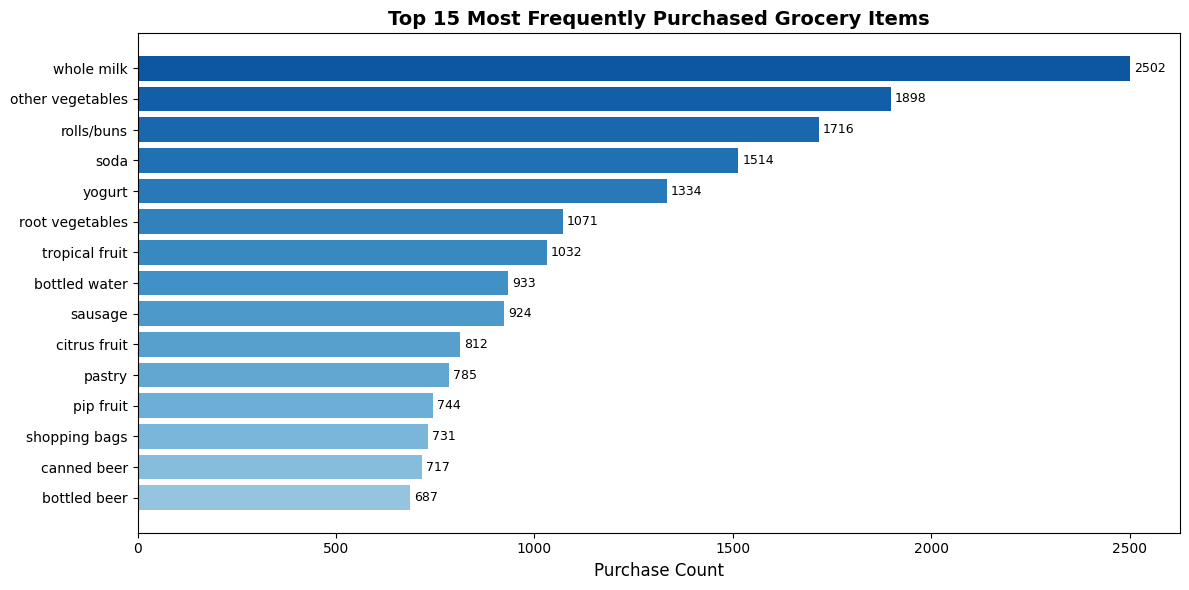

In [11]:
# ── 1: Top 15 Frequent Items Bar Chart ──────────────────────────────────────
top_items = df['itemDescription'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_items.index[::-1], top_items.values[::-1],
               color=plt.cm.Blues(np.linspace(0.4, 0.85, 15)))
ax.set_xlabel('Purchase Count', fontsize=12)
ax.set_title('Top 15 Most Frequently Purchased Grocery Items', fontsize=14, fontweight='bold')
for bar, val in zip(bars, top_items.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

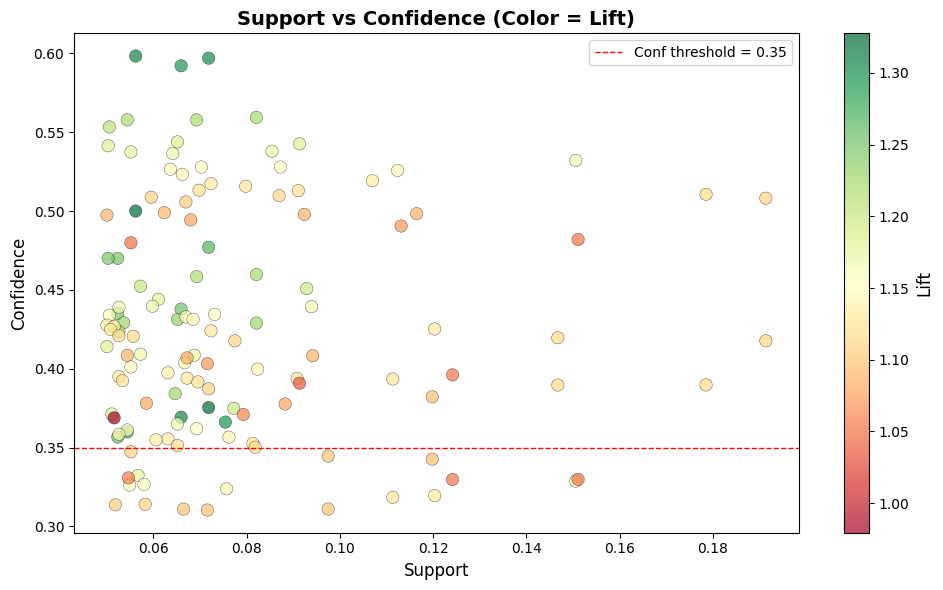

In [12]:
# ── 2: Support vs Confidence Scatter Plot ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(rules['support'], rules['confidence'],
                     c=rules['lift'], cmap='RdYlGn', s=80, alpha=0.7, edgecolors='k', linewidths=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Lift', fontsize=12)
ax.set_xlabel('Support', fontsize=12)
ax.set_ylabel('Confidence', fontsize=12)
ax.set_title('Support vs Confidence (Color = Lift)', fontsize=14, fontweight='bold')
ax.axhline(0.35, color='red', linestyle='--', linewidth=1, label='Conf threshold = 0.35')
ax.legend()
plt.tight_layout()
plt.show()

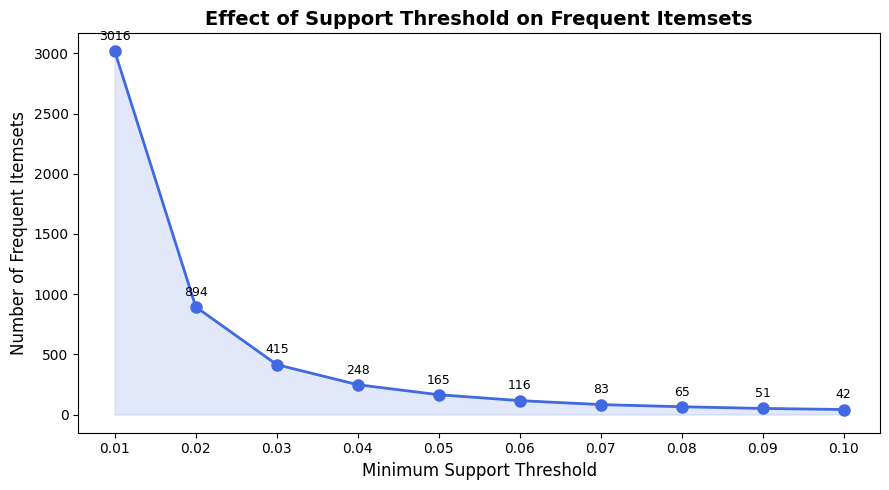

In [13]:
# ── 3: Effect of Support Threshold on Number of Frequent Itemsets ───────────
thresholds = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10]
counts = []
for t in thresholds:
    fi = apriori(df_encoded, min_support=t, use_colnames=True)
    counts.append(len(fi))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, counts, 'o-', color='royalblue', linewidth=2, markersize=8)
ax.fill_between(thresholds, counts, alpha=0.15, color='royalblue')
ax.set_xlabel('Minimum Support Threshold', fontsize=12)
ax.set_ylabel('Number of Frequent Itemsets', fontsize=12)
ax.set_title('Effect of Support Threshold on Frequent Itemsets', fontsize=14, fontweight='bold')
ax.set_xticks(thresholds)
for x, y in zip(thresholds, counts):
    ax.annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

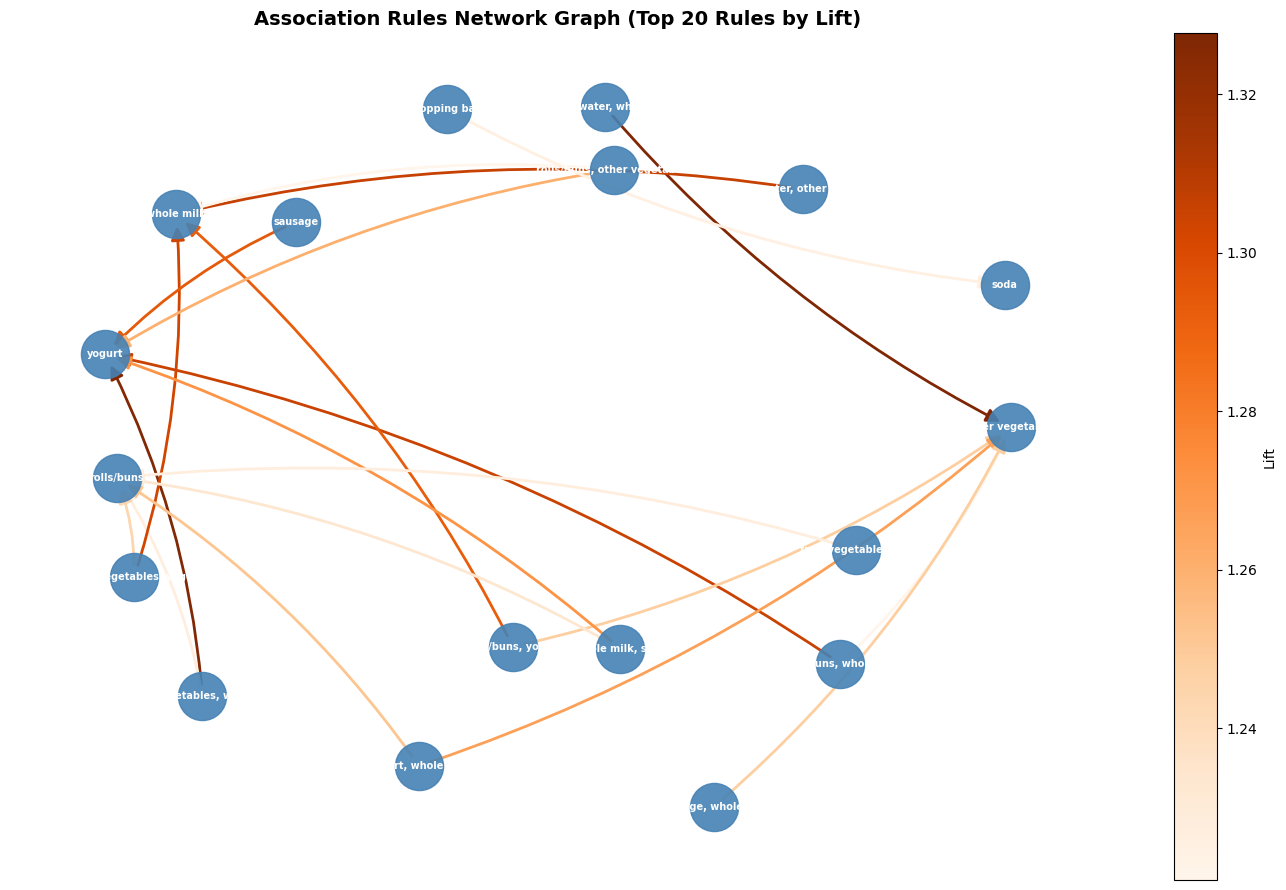

In [14]:
# ── 4: Association Rule Network Graph ───────────────────────────────────────
top_rules = rules.head(20).copy()
G = nx.DiGraph()

for _, row in top_rules.iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    G.add_edge(ant, con, weight=row['lift'], confidence=row['confidence'])

fig, ax = plt.subplots(figsize=(14, 9))
pos = nx.spring_layout(G, seed=42, k=2)
edge_weights = [G[u][v]['weight'] for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_color='steelblue', node_size=1200, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, font_color='white', font_weight='bold', ax=ax)
nx.draw_networkx_edges(G, pos, edge_color=edge_weights, edge_cmap=plt.cm.Oranges,
                       width=2, arrows=True, arrowsize=20, ax=ax,
                       connectionstyle='arc3,rad=0.1')

sm = plt.cm.ScalarMappable(cmap=plt.cm.Oranges,
                             norm=plt.Normalize(vmin=min(edge_weights), vmax=max(edge_weights)))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Lift')
ax.set_title('Association Rules Network Graph (Top 20 Rules by Lift)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

---

## SCENARIO 2 — DIMENSIONALITY REDUCTION USING PCA

**Problem Statement:** Reduce high-dimensional data into lower dimensions while preserving maximum variance using PCA.

**Dataset:** Wine Dataset (sklearn built-in) — 13 numerical features

### Task 1: Load Dataset

In [15]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='class')

print("Dataset shape:", X.shape)
print("Classes:", wine.target_names)
print("\nFirst 5 rows:")
X.head(5)

Dataset shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']

First 5 rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### Task 2 & 3: Data Preprocessing — Standardize Features

In [16]:
print("Missing values:", X.isnull().sum().sum())
print("\nFeature statistics before scaling:")
X.describe().round(2)

Missing values: 0

Feature statistics before scaling:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=wine.feature_names)

print("After StandardScaler — Mean (should be ~0):")
print(X_scaled_df.mean().round(4))
print("\nAfter StandardScaler — Std (should be ~1):")
print(X_scaled_df.std().round(4))

After StandardScaler — Mean (should be ~0):
alcohol                        -0.0
malic_acid                     -0.0
ash                            -0.0
alcalinity_of_ash              -0.0
magnesium                      -0.0
total_phenols                   0.0
flavanoids                     -0.0
nonflavanoid_phenols            0.0
proanthocyanins                -0.0
color_intensity                 0.0
hue                             0.0
od280/od315_of_diluted_wines    0.0
proline                        -0.0
dtype: float64

After StandardScaler — Std (should be ~1):
alcohol                         1.0028
malic_acid                      1.0028
ash                             1.0028
alcalinity_of_ash               1.0028
magnesium                       1.0028
total_phenols                   1.0028
flavanoids                      1.0028
nonflavanoid_phenols            1.0028
proanthocyanins                 1.0028
color_intensity                 1.0028
hue                             1.0028


### Task 4 & 5: Apply PCA — Compute Principal Components

In [18]:
# Full PCA (all 13 components) to study explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Explained Variance Ratio per Component:")
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f"  PC{i:2d}: {ev:.4f}  ({ev*100:.2f}%)  Cumulative: {cv*100:.2f}%")

Explained Variance Ratio per Component:
  PC 1: 0.3620  (36.20%)  Cumulative: 36.20%
  PC 2: 0.1921  (19.21%)  Cumulative: 55.41%
  PC 3: 0.1112  (11.12%)  Cumulative: 66.53%
  PC 4: 0.0707  (7.07%)  Cumulative: 73.60%
  PC 5: 0.0656  (6.56%)  Cumulative: 80.16%
  PC 6: 0.0494  (4.94%)  Cumulative: 85.10%
  PC 7: 0.0424  (4.24%)  Cumulative: 89.34%
  PC 8: 0.0268  (2.68%)  Cumulative: 92.02%
  PC 9: 0.0222  (2.22%)  Cumulative: 94.24%
  PC10: 0.0193  (1.93%)  Cumulative: 96.17%
  PC11: 0.0174  (1.74%)  Cumulative: 97.91%
  PC12: 0.0130  (1.30%)  Cumulative: 99.20%
  PC13: 0.0080  (0.80%)  Cumulative: 100.00%


### Task 6: Determine Explained Variance Ratio

In [19]:
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
n_components_90 = np.argmax(cumulative_var >= 0.90) + 1

print(f"Components needed to explain 90% variance: {n_components_90}")
print(f"Components needed to explain 95% variance: {n_components_95}")
print(f"Original features: 13  →  Reduced to: {n_components_95} (for 95% variance)")

Components needed to explain 90% variance: 8
Components needed to explain 95% variance: 10
Original features: 13  →  Reduced to: 10 (for 95% variance)


### Task 7: Reduce Dimensions to 2D and 3D

In [20]:
# 2D PCA
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)
df_2d = pd.DataFrame(X_2d, columns=['PC1', 'PC2'])
df_2d['class'] = y

print("2D PCA — Explained variance:", [f"{v:.4f}" for v in pca_2d.explained_variance_ratio_])
print(f"Total variance captured: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")

# 3D PCA
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_scaled)
df_3d = pd.DataFrame(X_3d, columns=['PC1', 'PC2', 'PC3'])
df_3d['class'] = y

print("\n3D PCA — Explained variance:", [f"{v:.4f}" for v in pca_3d.explained_variance_ratio_])
print(f"Total variance captured: {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")

2D PCA — Explained variance: ['0.3620', '0.1921']
Total variance captured: 55.41%

3D PCA — Explained variance: ['0.3620', '0.1921', '0.1112']
Total variance captured: 66.53%


### Task 8: Visualize Transformed Data

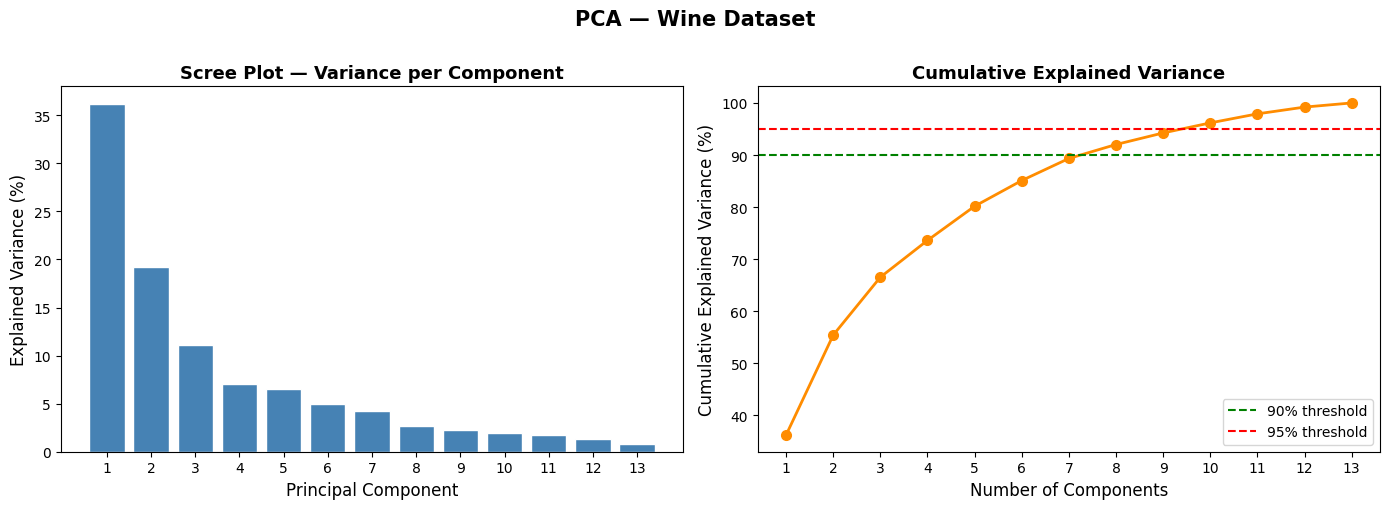

In [21]:
# ── 5: Scree Plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance
axes[0].bar(range(1, 14), explained_var * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance (%)', fontsize=12)
axes[0].set_title('Scree Plot — Variance per Component', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1, 14))

# Cumulative variance
axes[1].plot(range(1, 14), cumulative_var * 100, 'o-', color='darkorange', linewidth=2, markersize=7)
axes[1].axhline(90, color='green', linestyle='--', label='90% threshold')
axes[1].axhline(95, color='red', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(1, 14))
axes[1].legend()

plt.suptitle('PCA — Wine Dataset', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

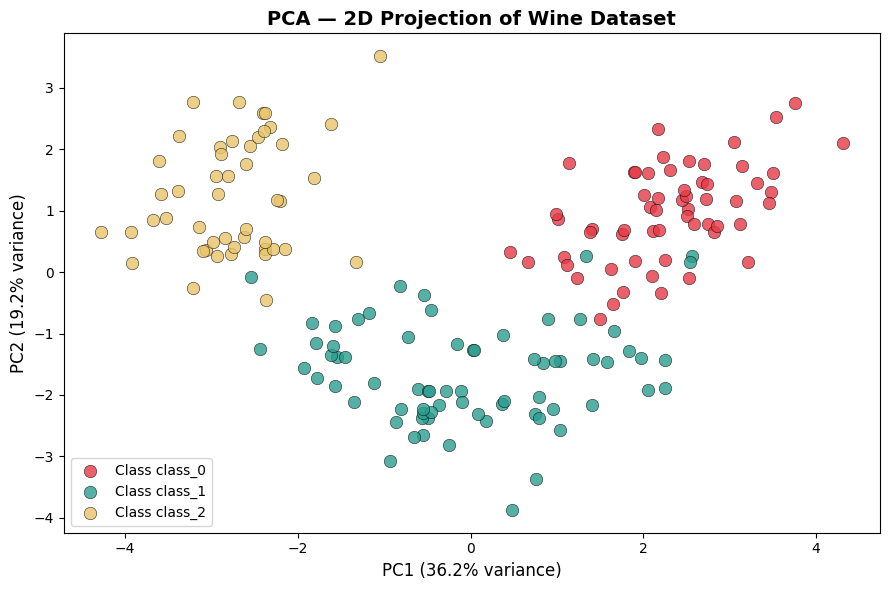

In [22]:
# ── 6: 2D PCA Scatter Plot ───────────────────────────────────────────────────
colors = ['#E63946', '#2A9D8F', '#E9C46A']
fig, ax = plt.subplots(figsize=(9, 6))

for cls, color in enumerate(colors):
    mask = df_2d['class'] == cls
    ax.scatter(df_2d.loc[mask, 'PC1'], df_2d.loc[mask, 'PC2'],
               c=color, label=f'Class {wine.target_names[cls]}',
               s=80, alpha=0.8, edgecolors='k', linewidths=0.4)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA — 2D Projection of Wine Dataset', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

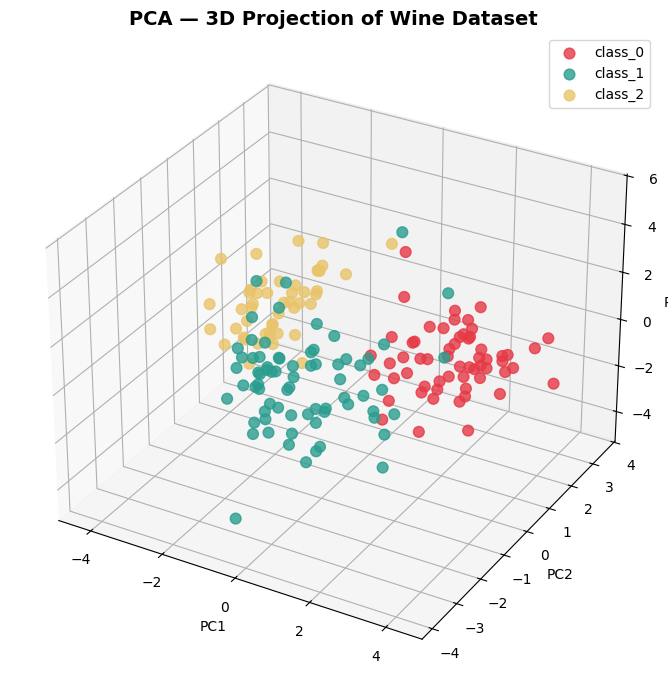

In [23]:
# ── 7: 3D PCA Scatter Plot ───────────────────────────────────────────────────
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for cls, color in enumerate(colors):
    mask = df_3d['class'] == cls
    ax.scatter(df_3d.loc[mask, 'PC1'], df_3d.loc[mask, 'PC2'], df_3d.loc[mask, 'PC3'],
               c=color, label=wine.target_names[cls], s=60, alpha=0.8)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('PCA — 3D Projection of Wine Dataset', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

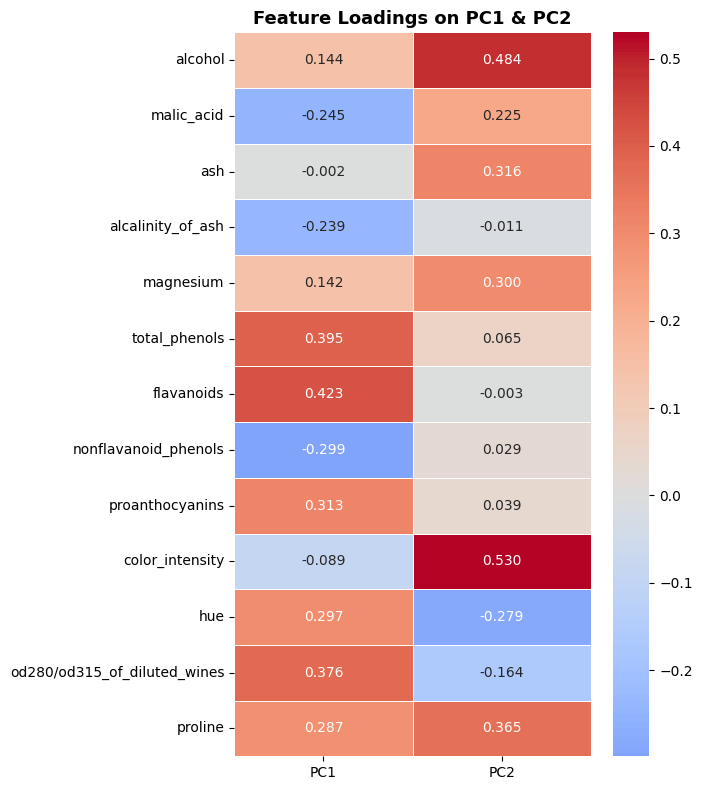

In [24]:
# ── 8: Feature Loadings Heatmap (PC1 and PC2) ────────────────────────────────
loadings = pd.DataFrame(pca_2d.components_.T,
                        index=wine.feature_names, columns=['PC1', 'PC2'])

fig, ax = plt.subplots(figsize=(7, 8))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Feature Loadings on PC1 & PC2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

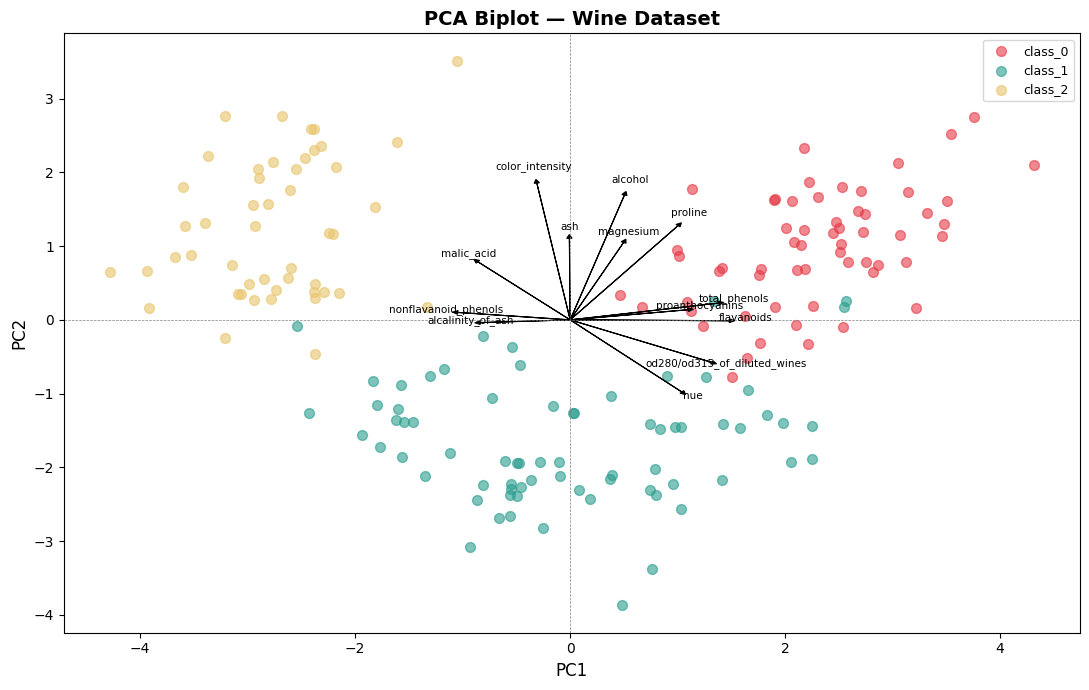

In [25]:
# ── 9: Biplot (PC1 vs PC2 with feature arrows) ───────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

for cls, color in enumerate(colors):
    mask = df_2d['class'] == cls
    ax.scatter(df_2d.loc[mask, 'PC1'], df_2d.loc[mask, 'PC2'],
               c=color, label=wine.target_names[cls], s=50, alpha=0.6)

scale = 3.5
for i, feat in enumerate(wine.feature_names):
    ax.arrow(0, 0, pca_2d.components_[0, i]*scale, pca_2d.components_[1, i]*scale,
             head_width=0.05, head_length=0.05, fc='black', ec='black', linewidth=0.8)
    ax.text(pca_2d.components_[0, i]*scale*1.1, pca_2d.components_[1, i]*scale*1.1,
            feat, fontsize=7.5, ha='center')

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('PCA Biplot — Wine Dataset', fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
plt.tight_layout()
plt.show()

### Evaluation Metrics — PCA

In [26]:
print("=== PCA EVALUATION METRICS ===")
print(f"\n  Original dimensions  : {X.shape[1]}")
print(f"  Reduced (2D)         : 2  |  Variance retained: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")
print(f"  Reduced (3D)         : 3  |  Variance retained: {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")
print(f"  Reduced (for 95% var): {n_components_95}  |  Variance retained: ≥95.00%")
print()
print("  Explained variance per PC (2D model):")
for i, ev in enumerate(pca_2d.explained_variance_ratio_, 1):
    print(f"    PC{i}: {ev*100:.2f}%")

=== PCA EVALUATION METRICS ===

  Original dimensions  : 13
  Reduced (2D)         : 2  |  Variance retained: 55.41%
  Reduced (3D)         : 3  |  Variance retained: 66.53%
  Reduced (for 95% var): 10  |  Variance retained: ≥95.00%

  Explained variance per PC (2D model):
    PC1: 36.20%
    PC2: 19.21%


---

## POST-LAB QUESTIONS

### Apriori Algorithm

**1. How are frequent itemsets generated?**  
Apriori starts with individual items satisfying min_support (1-itemsets). It then iteratively combines k-itemsets to generate (k+1)-itemsets, pruning any candidate whose sub-itemset is infrequent (anti-monotone principle). This continues until no new frequent itemsets can be generated.

**2. What is the significance of support and confidence?**  
Support tells us how often a pattern appears — low support means a rule is based on too few transactions (possibly noise). Confidence tells us the reliability of the rule — high confidence means the consequent almost always follows the antecedent.

**3. Why is Apriori computationally expensive?**  
Apriori requires multiple scans of the entire dataset — one per itemset size level. With many items, the number of candidate itemsets explodes combinatorially, and frequent database scans become very costly.

**4. How does lift improve rule selection?**  
Lift measures whether the rule is better than random chance. A lift of 1 means antecedent and consequent are independent. Lift > 1 shows a genuinely interesting, non-random co-occurrence, helping filter out spurious high-confidence rules where the consequent is just very common.

### Principal Component Analysis (PCA)

**1. What does PCA optimize?**  
PCA finds orthogonal directions (principal components) that maximize variance in the data. Each subsequent component maximizes remaining variance while being orthogonal to all previous ones.

**2. What is explained variance?**  
Explained variance ratio for each PC is the proportion of total dataset variance captured by that component. It tells us how much information is retained when projecting onto that axis.

**3. How are principal components formed?**  
PCA computes the covariance matrix of the standardized data, then finds its eigenvectors and eigenvalues. The eigenvectors are the principal components (directions of maximum variance), and eigenvalues represent the magnitude of variance along those directions.

**4. Limitations of PCA?**  
PCA is linear, so it cannot capture complex non-linear relationships. PCs are less interpretable than original features. It is sensitive to outliers. Standardization is required. It may discard features with low variance that are still informative.

### Conceptual Questions

**1. Difference between supervised and unsupervised learning:**  
Supervised learning uses labeled data (input → output pairs) to learn a mapping function. Unsupervised learning discovers hidden patterns or structure in unlabeled data. Apriori and PCA are both unsupervised.

**2. Compare Apriori and PCA:**  
Apriori finds item co-occurrence patterns in categorical transactional data. PCA reduces dimensionality of continuous numerical data by finding orthogonal variance-maximizing axes. Both are unsupervised but address entirely different problem types.

**3. Why is dimensionality reduction needed?**  
High-dimensional data suffers from the curse of dimensionality — data becomes sparse, distances lose meaning, and models overfit. Dimensionality reduction mitigates these issues, reduces storage/computation, and often improves model performance.

**4. Real-world applications of association rule mining:**  
Market basket analysis (retail), cross-selling recommendations, medical diagnosis (symptom co-occurrences), web clickstream analysis, fraud detection, document clustering, and inventory management.

**5. How can PCA improve model performance?**  
By removing noisy/redundant features, PCA can reduce overfitting and speed up training. Decorrelated features (orthogonal PCs) can also help algorithms that assume feature independence, like Naïve Bayes or linear regression.

---
**End of Experiment 8**